In [2]:
from torch import nn
import kagglehub
import torch
from torch import Tensor
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from torchvision import datasets, transforms
from torchvision.models import alexnet
from torch.nn import functional as F
import torchvision.models as models
from torch.optim import Adam, SGD
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import DataLoader, random_split, Subset, ConcatDataset
import seaborn as sns
from PIL import Image
from pathlib import Path
from torch.optim.lr_scheduler import StepLR
from typing import Optional, Tuple, List, Callable, Any
from timeit import default_timer as timer

/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/var-roman/.cache/kagglehub/datasets/solothok/cat-breed/versions/1/cat-breed
Shape of tensor: torch.Size([32, 3, 299, 299])
Shape of tensor with labels: torch.Size([32])
Example of label: 3


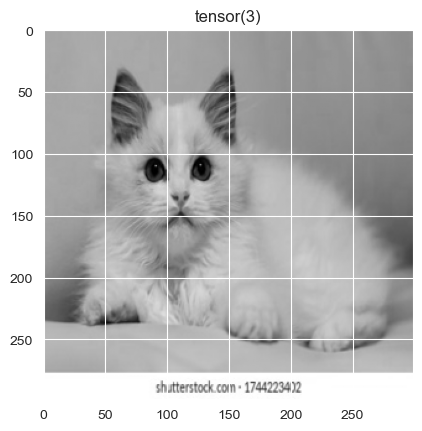

torch.Size([299, 299]) torch.Size([])


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not Path('/home/var-roman/.cache/kagglehub/datasets/solothok/cat-breed/versions/1/cat-breed').exists():
    dataset_path = kagglehub.dataset_download("solothok/cat-breed")
else:
    dataset_path = '/home/var-roman/.cache/kagglehub/datasets/solothok/cat-breed/versions/1/cat-breed'
print("Path to dataset files:", dataset_path)

IMG_SIZE = 299

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ])


train_dataset = datasets.ImageFolder(root=dataset_path + '/TRAIN', transform=basic_transform)
test_dataset = datasets.ImageFolder(root=dataset_path + '/TEST', transform=basic_transform)
generator = torch.Generator()

additional_train_dataset, augment_train_dataset = random_split(train_dataset, [len(train_dataset) // 2, len(train_dataset) // 2], generator=generator)

# augment_train_dataset.dataset.transform = train_transform
# train_dataset = ConcatDataset([train_dataset, augment_train_dataset])

BATCH_SIZE = 32
NUM_WORKERS = 4
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS,
                              pin_memory=True)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=NUM_WORKERS,
                             pin_memory=True)

images, labels = next(iter(train_dataloader))

print(f'Shape of tensor: {images.shape}')
print(f'Shape of tensor with labels: {labels.shape}')
print(f'Example of label: {labels[0]}')
plt.imshow(images[0][0].squeeze(), cmap='gray')
plt.title(labels[0])
plt.show()
print(images[0][0].shape, labels[0].shape)

In [4]:
class_names = ['0 - americanshorthair',
               '1 - bengal',
               '2 - mainecoon',
               '3 - ragdoll',
               '4 - scottishfold',
               '5 - sphinx']
NUM_CLASSES = 6

torch.cuda.is_available()

True

In [20]:
def training_step(model: torch.nn.Module,
                  data_loader: torch.utils.data.DataLoader,
                  loss_fn: torch.nn.Module,
                  optimizer: torch.optim.Optimizer,) -> float: # Повертатимемо float

    loss_count: float = 0.0
    model.train()
    model.to(device)

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        main_output, aux_output = model(X)

        loss1 = loss_fn(main_output, y)
        loss2 = loss_fn(aux_output, y)

        loss = loss1 + 0.3 * loss2
        loss_count += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_count /= len(data_loader)

    return loss_count


def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    all_preds = []
    all_labels = []
    test_loss = 0
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)
            preds = torch.argmax(test_pred, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        test_loss /= len(data_loader)

        return test_loss, all_preds, all_labels


def save_model(model: torch.nn.Module, model_name: str):
    model_path = Path("models")
    model_path.mkdir(parents=True,
                     exist_ok=True)

    model_full_name = f"{model_name}.pth"
    model_save_path = model_path / model_full_name

    print(f"Saving model to: {model_save_path}")
    torch.save(obj=model.state_dict(), f=model_save_path)

def load_model(model: torch.nn.Module, model_name: str) -> torch.nn.Module:
    model_path = Path("models")
    model_full_name = f"{model_name}.pth"
    model_save_path = model_path / model_full_name
    model.load_state_dict(torch.load(f=model_save_path,weights_only=True))
    model = model.to(device)
    return model

def predict_image(model: torch.nn.Module, image_path: str, transform: transforms.Compose, class_names: list):
    try:
        img = Image.open(image_path)
    except FileNotFoundError:
        print(f"Помилка: Не вдалося знайти файл зображення за шляхом {image_path}")
        return None, None
    except Exception as e:
        print(f"Помилка: Не вдалося відкрити зображення {image_path}. {e}")
        return None, None
    model.to(device)
    model.eval()
    try:
        img_transformed = transform(img).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Помилка під час трансформації зображення: {e}")
        return None, None
    with torch.inference_mode():
        pred_logits = model(img_transformed)
        pred_prob = torch.softmax(pred_logits, dim=1)
        pred_label = torch.argmax(pred_prob, dim=1)

    pred_class_name = class_names[pred_label.cpu().item()]
    predicted_probability = pred_prob.max().cpu().item()
    return pred_class_name, predicted_probability

def calc_metrics(y_preds, y_true, epochs_train_lt, epochs_test_lt,
                 epochs_num, model_name, num_classes):

    acc_fn = Accuracy(task="multiclass", num_classes=num_classes)
    accuracy = acc_fn(y_preds, y_true)
    print(f"Загальна точність (Accuracy): {accuracy.item():.4f}")

    conf_matrix_fn = ConfusionMatrix(task="multiclass", num_classes=num_classes)
    prec_fn_macro = Precision(task="multiclass", num_classes=num_classes, average='macro')
    recall_fn_macro = Recall(task="multiclass", num_classes=num_classes, average='macro')
    f1_fn_macro = F1Score(task="multiclass", num_classes=num_classes, average='macro')

    conf_matrix = conf_matrix_fn(y_preds, y_true).numpy()
    precision_macro = prec_fn_macro(y_preds, y_true)
    recall_macro = recall_fn_macro(y_preds, y_true)
    f1_macro = f1_fn_macro(y_preds, y_true)

    print(f"Усереднена прецизійність (Macro Precision): {precision_macro.item():.4f}")
    print(f"Усереднена повнота (Macro Recall): {recall_macro.item():.4f}")
    print(f"Усереднений F1-Score (Macro F1-Score): {f1_macro.item():.4f}")

    fig, ax = plt.subplots(nrows=2, figsize=(12, 10))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax = ax[0]
    )
    ax[0].set_xlabel('Передбачений клас (Predicted Label)')
    ax[0].set_ylabel('Справжній клас (True Label)')
    ax[0].set_title('Матриця помилок (Confusion Matrix)')

    ax[1].plot(range(epochs_num), epochs_train_lt, label="Train loss")
    ax[1].plot(range(epochs_num), epochs_test_lt, label="Test loss")
    ax[1].set_title(f"Модель: {model_name}")
    ax[1].set_ylabel("Loss")
    ax[1].set_xlabel("Epochs")
    ax[1].legend()
    plt.show()

def predict_image(model: torch.nn.Module, image_path: str, transform: transforms.Compose, class_names: list):
    try:
        img = Image.open(image_path)
    except FileNotFoundError:
        print(f"Помилка: Не вдалося знайти файл зображення за шляхом {image_path}")
        return None, None
    except Exception as e:
        print(f"Помилка: Не вдалося відкрити зображення {image_path}. {e}")
        return None, None
    model.to(device)
    model.eval()
    try:
        img_transformed = transform(img).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Помилка під час трансформації зображення: {e}")
        return None, None
    with torch.inference_mode():
        pred_logits = model(img_transformed)
        pred_prob = torch.softmax(pred_logits, dim=1)
        pred_label = torch.argmax(pred_prob, dim=1)

    pred_class_name = class_names[pred_label.cpu().item()]
    predicted_probability = pred_prob.max().cpu().item()
    return pred_class_name, predicted_probability

In [6]:
def print_train_time(start, end):
        total_time = end - start
        print(f"Загальний час тренування на {device}: {total_time:.3f} секунд")
        return total_time


class BasicConv2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, **kwargs) -> None:
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels ,eps=0.001, momentum=0.1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


class InceptionAux(nn.Module):
    """
    Допоміжний класифікатор. Прикріплюється до сітки 17x17.
    """
    def __init__(self, in_channels: int, num_classes: int) -> None:
        super().__init__()
        self.pool = nn.AvgPool2d(kernel_size=5, stride=3)
        self.conv0 = BasicConv2d(in_channels, 128, kernel_size=1)
        self.conv1 = BasicConv2d(128, 768, kernel_size=5)
        self.conv1.conv.stddev = 0.01

        self.fc = nn.Linear(768, num_classes)
        self.fc.stddev = 0.001

    def forward(self, x: Tensor) -> Tensor:
        x = self.pool(x)
        x = self.conv0(x)
        x = self.conv1(x)

        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


class InceptionA(nn.Module):
    def __init__(self, in_channels: int, pool_features: int) -> None:
        super(InceptionA, self).__init__()
        self.branch1x1 = BasicConv2d(in_channels, 64, kernel_size=1)

        self.branch3x3_1 = BasicConv2d(in_channels, 48, kernel_size=1)
        self.branch3x3_2 = BasicConv2d(48, 64, kernel_size=3, padding=1)

        self.branch3x3dbl_1 = BasicConv2d(in_channels, 64, kernel_size=1)
        self.branch3x3dbl_2 = BasicConv2d(64, 96, kernel_size=3, padding=1)
        self.branch3x3dbl_3 = BasicConv2d(96, 96, kernel_size=3, padding=1)

        self.branch_pool_conv = BasicConv2d(in_channels, pool_features, kernel_size=1)
        self.branch_pool_pool = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)

    def forward(self, x: Tensor) -> Tensor:
        b1 = self.branch1x1(x)

        b2 = self.branch3x3_1(x)
        b2 = self.branch3x3_2(b2)

        b3 = self.branch3x3dbl_1(x)
        b3 = self.branch3x3dbl_2(b3)
        b3 = self.branch3x3dbl_3(b3)

        b4 = self.branch_pool_pool(x)
        b4 = self.branch_pool_conv(b4)

        return torch.cat([b1, b2, b3, b4], 1)


class InceptionB(nn.Module):
    def __init__(self, in_channels: int) -> None:
        super(InceptionB, self).__init__()
        self.branch3x3 = BasicConv2d(in_channels, 384, kernel_size=3, stride=2)

        self.branch3x3dbl_1 = BasicConv2d(in_channels, 64, kernel_size=1)
        self.branch3x3dbl_2 = BasicConv2d(64, 96, kernel_size=3, padding=1)
        self.branch3x3dbl_3 = BasicConv2d(96, 96, kernel_size=3, stride=2)

        self.branch_pool = nn.MaxPool2d(kernel_size=3, stride=2)

    def forward(self, x: Tensor) -> Tensor:
        b1 = self.branch3x3(x)

        b2 = self.branch3x3dbl_1(x)
        b2 = self.branch3x3dbl_2(b2)
        b2 = self.branch3x3dbl_3(b2)

        b3 = self.branch_pool(x)

        return torch.cat([b1, b2, b3], 1)


class InceptionC(nn.Module):
    def __init__(self, in_channels: int, channels_7x7: int) -> None:
        super(InceptionC, self).__init__()
        self.branch1x1 = BasicConv2d(in_channels, 192, kernel_size=1)

        c = channels_7x7
        self.branch7x7_1 = BasicConv2d(in_channels, c, kernel_size=1)
        self.branch7x7_2 = BasicConv2d(c, c, kernel_size=(1, 7), padding=(0, 3))
        self.branch7x7_3 = BasicConv2d(c, 192, kernel_size=(7, 1), padding=(3, 0))

        self.branch7x7dbl_1 = BasicConv2d(in_channels, c, kernel_size=1)
        self.branch7x7dbl_2 = BasicConv2d(c, c, kernel_size=(7, 1), padding=(3, 0))
        self.branch7x7dbl_3 = BasicConv2d(c, c, kernel_size=(1, 7), padding=(0, 3))
        self.branch7x7dbl_4 = BasicConv2d(c, c, kernel_size=(7, 1), padding=(3, 0))
        self.branch7x7dbl_5 = BasicConv2d(c, 192, kernel_size=(1, 7), padding=(0, 3))

        self.branch_pool_conv = BasicConv2d(in_channels, 192, kernel_size=1)
        self.branch_pool_pool = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)

    def forward(self, x: Tensor) -> Tensor:
        b1 = self.branch1x1(x)

        b2 = self.branch7x7_1(x)
        b2 = self.branch7x7_2(b2)
        b2 = self.branch7x7_3(b2)

        b3 = self.branch7x7dbl_1(x)
        b3 = self.branch7x7dbl_2(b3)
        b3 = self.branch7x7dbl_3(b3)
        b3 = self.branch7x7dbl_4(b3)
        b3 = self.branch7x7dbl_5(b3)

        b4 = self.branch_pool_pool(x)
        b4 = self.branch_pool_conv(b4)

        return torch.cat([b1, b2, b3, b4], 1)


class InceptionD(nn.Module):
    def __init__(self, in_channels: int) -> None:
        super(InceptionD, self).__init__()
        self.branch3x3_1 = BasicConv2d(in_channels, 192, kernel_size=1)
        self.branch3x3_2 = BasicConv2d(192, 320, kernel_size=3, stride=2)

        self.branch7x7x3_1 = BasicConv2d(in_channels, 192, kernel_size=1)
        self.branch7x7x3_2 = BasicConv2d(192, 192, kernel_size=(1, 7), padding=(0, 3))
        self.branch7x7x3_3 = BasicConv2d(192, 192, kernel_size=(7, 1), padding=(3, 0))
        self.branch7x7x3_4 = BasicConv2d(192, 192, kernel_size=3, stride=2)

        self.branch_pool = nn.MaxPool2d(kernel_size=3, stride=2)

    def forward(self, x: Tensor) -> Tensor:
        b1 = self.branch3x3_1(x)
        b1 = self.branch3x3_2(b1)

        b2 = self.branch7x7x3_1(x)
        b2 = self.branch7x7x3_2(b2)
        b2 = self.branch7x7x3_3(b2)
        b2 = self.branch7x7x3_4(b2)

        b3 = self.branch_pool(x)

        return torch.cat([b1, b2, b3], 1)


class InceptionE(nn.Module):
    def __init__(self, in_channels: int) -> None:
        super(InceptionE, self).__init__()
        self.branch1x1 = BasicConv2d(in_channels, 320, kernel_size=1)

        self.branch3x3_1 = BasicConv2d(in_channels, 384, kernel_size=1)
        self.branch3x3_2a = BasicConv2d(384, 384, kernel_size=(1, 3), padding=(0, 1))
        self.branch3x3_2b = BasicConv2d(384, 384, kernel_size=(3, 1), padding=(1, 0))

        self.branch3x3dbl_1 = BasicConv2d(in_channels, 448, kernel_size=1)
        self.branch3x3dbl_2 = BasicConv2d(448, 384, kernel_size=3, padding=1)
        self.branch3x3dbl_3a = BasicConv2d(384, 384, kernel_size=(1, 3), padding=(0, 1))
        self.branch3x3dbl_3b = BasicConv2d(384, 384, kernel_size=(3, 1), padding=(1, 0))

        self.branch_pool_conv = BasicConv2d(in_channels, 192, kernel_size=1)
        self.branch_pool_pool = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)

    def forward(self, x: Tensor) -> Tensor:
        b1 = self.branch1x1(x)

        b2 = self.branch3x3_1(x)
        b2_a = self.branch3x3_2a(b2)
        b2_b = self.branch3x3_2b(b2)
        b2 = torch.cat([b2_a, b2_b], 1)

        b3 = self.branch3x3dbl_1(x)
        b3 = self.branch3x3dbl_2(b3)
        b3_a = self.branch3x3dbl_3a(b3)
        b3_b = self.branch3x3dbl_3b(b3)
        b3 = torch.cat([b3_a, b3_b], 1)

        b4 = self.branch_pool_pool(x)
        b4 = self.branch_pool_conv(b4)

        return torch.cat([b1, b2, b3, b4], 1)


class InceptionV3(nn.Module):
    def __init__(self, num_classes: int = 1000, aux_logits: bool = True, modify_state: bool = False) -> None:
        super(InceptionV3, self).__init__()
        self.modify_state = modify_state
        self.aux_logits = aux_logits
        self.Conv2d_1a_3x3 = BasicConv2d(3, 32, kernel_size=3, stride=2)
        self.Conv2d_2a_3x3 = BasicConv2d(32, 32, kernel_size=3)
        self.Conv2d_2b_3x3 = BasicConv2d(32, 64, kernel_size=3, padding=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.Conv2d_3b_1x1 = BasicConv2d(64, 80, kernel_size=1)
        self.Conv2d_4a_3x3 = BasicConv2d(80, 192, kernel_size=3)
        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2)

        self.Mixed_5b = InceptionA(192, pool_features=32)
        self.Mixed_5c = InceptionA(256, pool_features=64)
        self.Mixed_5d = InceptionA(288, pool_features=64)

        self.Mixed_6a = InceptionB(288)

        self.Mixed_6b = InceptionC(768, channels_7x7=128)
        self.Mixed_6c = InceptionC(768, channels_7x7=160)
        self.Mixed_6d = InceptionC(768, channels_7x7=160)
        self.Mixed_6e = InceptionC(768, channels_7x7=192)

        if aux_logits:
            self.AuxLogits = InceptionAux(768, num_classes)

        self.Mixed_7a = InceptionD(768)
        self.Mixed_7b = InceptionE(1280)
        self.Mixed_7c = InceptionE(2048)

        if not self.modify_state:
            self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
            self.dropout = nn.Dropout(p=0.5)
            self.flatten = nn.Flatten()
            self.fc = nn.Linear(2048, num_classes)
            self._initialize_weights()
        else:
            self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
            self.flatten = nn.Flatten()

            # Створюємо потужнішу "голову"
            self.fc = nn.Sequential(
                nn.Linear(2048, 512), # Перший шар (обробка ознак)
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(512),    # Нормалізація
                nn.Dropout(p=0.4),      # Менший Dropout
                nn.Linear(512, num_classes) # Фінальний шар (класифікація)
            )

    def _initialize_weights(self):
        for m in self.modules():
            # Використовуємо 'isinstance' з кортежем для чистоти коду
            if isinstance(m, (nn.Conv2d, nn.Linear)):

                # Перевіряємо, чи має цей конкретний шар прапорець 'stddev'
                if hasattr(m, 'stddev'):
                    # Якщо так, це шар з AuxLogits, ініціалізуємо його по-особливому
                    nn.init.trunc_normal_(m.weight, mean=0.0, std=m.stddev, a=-2.0, b=2.0)
                    if m.bias is not None:
                        nn.init.constant_(m.bias, 0)
                else:
                    # Це звичайний шар, ініціалізуємо за Kaiming (He)
                    nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                    # bias в Conv2d у нас False, а в Linear ініціалізується за замовчуванням

            elif isinstance(m, nn.BatchNorm2d):
                # BatchNorm ініціалізуємо одиницями та нулями
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _forward(self, x: Tensor) -> Tuple[Tensor, Optional[Tensor]]:
        aux: Optional[Tensor] = None

        x = self.Conv2d_1a_3x3(x)
        x = self.Conv2d_2a_3x3(x)
        x = self.Conv2d_2b_3x3(x)
        x = self.maxpool1(x)
        x = self.Conv2d_3b_1x1(x)
        x = self.Conv2d_4a_3x3(x)
        x = self.maxpool2(x)

        # InceptionA
        x = self.Mixed_5b(x)
        x = self.Mixed_5c(x)
        x = self.Mixed_5d(x)

        x = self.Mixed_6a(x)

        # InceptionC
        x = self.Mixed_6b(x)
        x = self.Mixed_6c(x)
        x = self.Mixed_6d(x)
        x = self.Mixed_6e(x)

        if self.training and self.aux_logits:
            aux = self.AuxLogits(x)

        # Grid Reduction B
        x = self.Mixed_7a(x) # 8x8

        # InceptionE
        x = self.Mixed_7b(x)
        x = self.Mixed_7c(x)

        # Head

        x = self.avgpool(x)
        x = self.flatten(x)
        if not self.modify_state:
            x = self.dropout(x)
        main_output = self.fc(x)

        return main_output, aux

    def forward(self, x: Tensor) -> Tensor | Tuple[Tensor, Tensor]:
        main_output, aux_output = self._forward(x)

        if self.training and self.aux_logits:
            return main_output, aux_output
        else:
            return main_output

In [11]:
model = InceptionV3(num_classes=NUM_CLASSES, aux_logits=True, modify_state=False)
model.to(device)

weights_obj = models.Inception_V3_Weights.IMAGENET1K_V1
pretrained_weights = weights_obj.get_state_dict()

keys_to_remove = [
    'fc.weight',
    'fc.bias',
    'AuxLogits.fc.weight',
    'AuxLogits.fc.bias'
]
for key in keys_to_remove:
    if key in pretrained_weights:
        pretrained_weights.pop(key)
        print(f"Removed key: {key}")

print("\nLoading pre-trained weights...")
model.load_state_dict(pretrained_weights, strict=False)
print("Weights loaded successfully!")

for param in model.parameters():
    param.requires_grad = False

print("\nUnfreezing layers for training:")
for m in [model.fc,
          model.AuxLogits.fc,
          # model_2.Mixed_7c,
          # model_2.Mixed_7b,
          ]:
    if m is not None:
        for param in m.parameters():
            param.requires_grad = True
            print(f" - {m.__class__.__name__} (param shape: {param.shape})")

params_to_train = [p.shape for p in model.parameters() if p.requires_grad]
print(f"\nParameters to be trained: {params_to_train}")
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001)
criterion = nn.CrossEntropyLoss()

Removed key: fc.weight
Removed key: fc.bias
Removed key: AuxLogits.fc.weight
Removed key: AuxLogits.fc.bias

Loading pre-trained weights...
Weights loaded successfully!

Unfreezing layers for training:
 - Linear (param shape: torch.Size([6, 2048]))
 - Linear (param shape: torch.Size([6]))
 - Linear (param shape: torch.Size([6, 768]))
 - Linear (param shape: torch.Size([6]))

Parameters to be trained: [torch.Size([6, 768]), torch.Size([6]), torch.Size([6, 2048]), torch.Size([6])]


In [7]:
def training_process(num_epoch: int,
                     model: torch.nn.Module,
                     optimizer: torch.optim.Optimizer,
                     loss_fn: torch.nn.Module,
                     train_loader: DataLoader,
                     test_loader: DataLoader):
    train_time_start_on_gpu = timer()

    epochs_train_lt_1 = []
    epochs_test_lt_1 = []

    epochs = num_epoch
    for epoch in tqdm(range(epochs)):
        print(f"Epoch: {epoch}\n---------")

        train_loss_value = training_step(data_loader=train_loader,
                                         model=model,
                                         loss_fn=loss_fn,
                                         optimizer=optimizer)
        epochs_train_lt_1.append(train_loss_value)
        test_loss_var_1, y_preds_1, y_true_1 = test_step(data_loader=test_loader,
                                                         model=model,
                                                         loss_fn=loss_fn)

        epochs_test_lt_1.append(test_loss_var_1.cpu().item())

        print(f"Train loss: {train_loss_value:.4f} | Test loss: {test_loss_var_1.cpu().item():.4f}")


    train_time_end_on_gpu = timer()


    total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                                end=train_time_end_on_gpu)

    return epochs_train_lt_1, epochs_test_lt_1, y_preds_1, y_true_1, total_train_time_model_1

In [ ]:
epochs_count = 100
epochs_train_lt_1, epochs_test_lt_1, y_preds_1, y_true_1, total_train_time_model_1 = training_process(epochs_count, model, optimizer, criterion, train_dataloader, test_dataloader)

Загальна точність (Accuracy): 0.6167
Усереднена прецизійність (Macro Precision): 0.6180
Усереднена повнота (Macro Recall): 0.6167
Усереднений F1-Score (Macro F1-Score): 0.6168


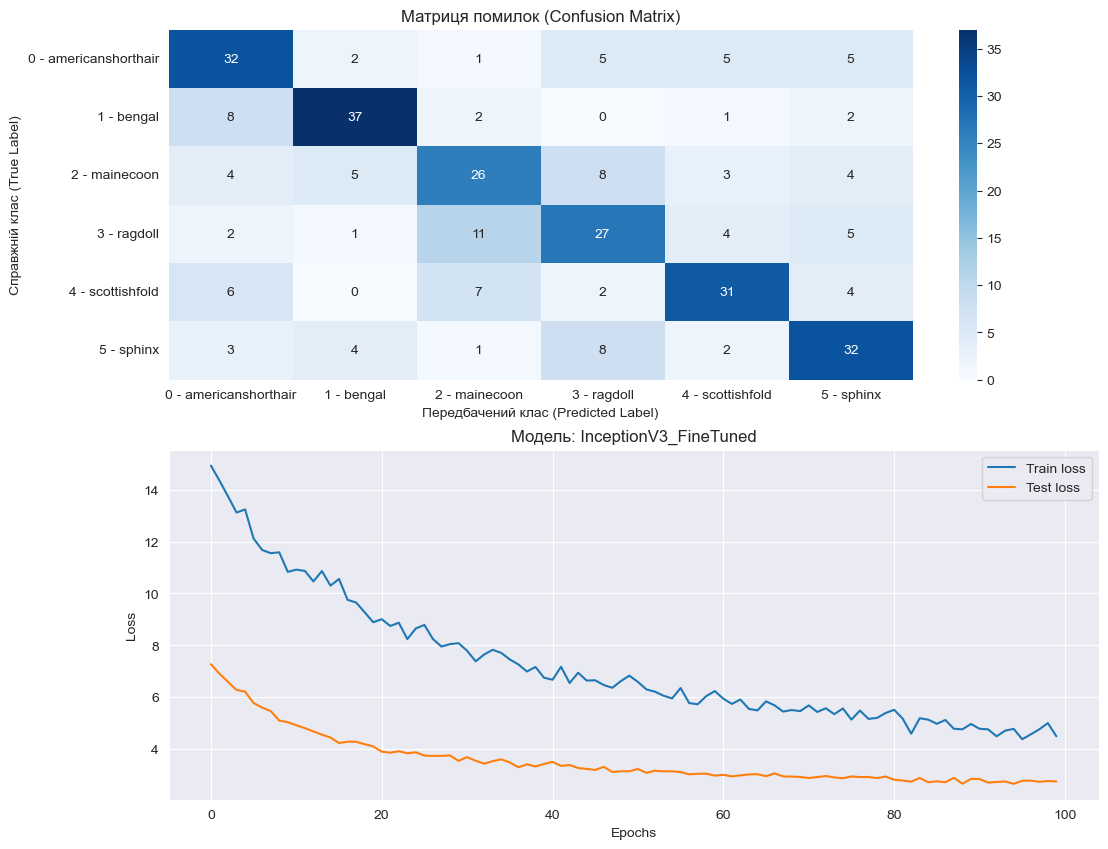

In [58]:
calc_metrics(y_preds=y_preds_1,
             y_true=y_true_1,
             epochs_train_lt=epochs_train_lt_1,
             epochs_test_lt=epochs_test_lt_1,
             epochs_num=epochs_count,
             model_name="InceptionV3_FineTuned",
             num_classes=NUM_CLASSES)

In [ ]:
save_model(model=model, model_name='InceptionV3_FineTuned_v1.1_F_1_e3')

## Second part

In [8]:
model_names_lt = [
    "InceptionV3_FineTuned_v0_1_e3",
    "InceptionV3_FineTuned_v0_1_e3_augment",
    "InceptionV3_FineTuned_v0_1_e4",
    "InceptionV3_FineTuned_v0_1_e4_augment",
    "InceptionV3_FineTuned_v0_5_e4",
    "InceptionV3_FineTuned_v0_5_e4_augment",
                  ]

model_names_lt_1 = [
    "InceptionV3_FineTuned_v1_1_e3",
    "InceptionV3_FineTuned_v1_1_e3_augment",
    "InceptionV3_FineTuned_v1.1_1_e3",
    "InceptionV3_FineTuned_v1.1_F_1_e3",
]

model_names_lt_2 = [
    "InceptionV3_FineTuned_v2.0_M_1_e5",
    "InceptionV3_FineTuned_v2.0_M_1_e5_augment",
    "InceptionV3_FineTuned_v2.1_M_1_e5_augment",
    "InceptionV3_FineTuned_v2.1_M_1_e5",
    "InceptionV3_FineTuned_v2.1_M_1_e6",
]

print('Models V0')
if model_names_lt:
    for num, i in enumerate(model_names_lt):
        my_model = load_model(InceptionV3(6), i)
        print(f'{num}. Model {i}: {test_step(my_model, data_loader=test_dataloader, loss_fn=criterion)[0].cpu().item():.4f}')

print('\nModels V1')
for num, i in enumerate(model_names_lt_1):
    if '_F_' in i:
        modify_state = False
    else:
        modify_state = True
    my_model = load_model(InceptionV3(6, modify_state=modify_state), i)
    print(f'{num}. Model {i}: {test_step(my_model, data_loader=test_dataloader, loss_fn=criterion)[0].cpu().item():.4f}')

print('\nModels V2')
for num, i in enumerate(model_names_lt_2):
    if '_M_' in i:
        modify_state = True
    else:
        modify_state = False
    my_model = load_model(InceptionV3(6, modify_state=modify_state), i)
    print(f'{num}. Model {i}: {test_step(my_model, data_loader=test_dataloader, loss_fn=criterion)[0].cpu().item():.4f}')

Models V0


NameError: name 'criterion' is not defined

In [66]:
test_step(my_model, data_loader=test_dataloader, loss_fn=criterion)[0]

tensor(1.6313, device='cuda:0')

In [ ]:
# model_2 = load_model(InceptionV3(num_classes=NUM_CLASSES, modify_state=True), "InceptionV3_FineTuned_v1_1_e3_augment")
model_2 = InceptionV3(num_classes=NUM_CLASSES, modify_state=True)

In [ ]:
model_2.to(device)

for param in model_2.parameters():
    param.requires_grad = False

layers_to_unfreeze = [
    model_2.fc,
    model_2.AuxLogits.fc,
    model_2.Mixed_7c,
    model_2.Mixed_7b,
    model_2.Mixed_7a,
    model.Mixed_6e,
    model.Mixed_6d,
    model.Mixed_6c,
    model.Mixed_6b,
    model.Mixed_6a
]

for layer in layers_to_unfreeze:
    for param in layer.parameters():
        param.requires_grad = True

optimizer_2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_2.parameters()),
    lr=1e-6
)
criterion = nn.CrossEntropyLoss()

In [ ]:
epochs_count = 100
epochs_train_lt_1, epochs_test_lt_1, y_preds_1, y_true_1, total_train_time_model_1 = training_process(epochs_count, model_2, optimizer_2, criterion, train_dataloader, test_dataloader)

In [ ]:
calc_metrics(y_preds=y_preds_1,
             y_true=y_true_1,
             epochs_train_lt=epochs_train_lt_1,
             epochs_test_lt=epochs_test_lt_1,
             epochs_num=epochs_count,
             model_name="InceptionV3_FineTuned",
             num_classes=NUM_CLASSES)

In [ ]:
save_model(model=model_2, model_name='InceptionV3_FineTuned_v2.1_M_1_e6')

## Third part

In [12]:
my_model = load_model(InceptionV3(6, modify_state=True), 'InceptionV3_FineTuned_v1_1_e3_augment')

Загальна точність (Accuracy): 0.6333
Усереднена прецизійність (Macro Precision): 0.6552
Усереднена повнота (Macro Recall): 0.6333
Усереднений F1-Score (Macro F1-Score): 0.6364


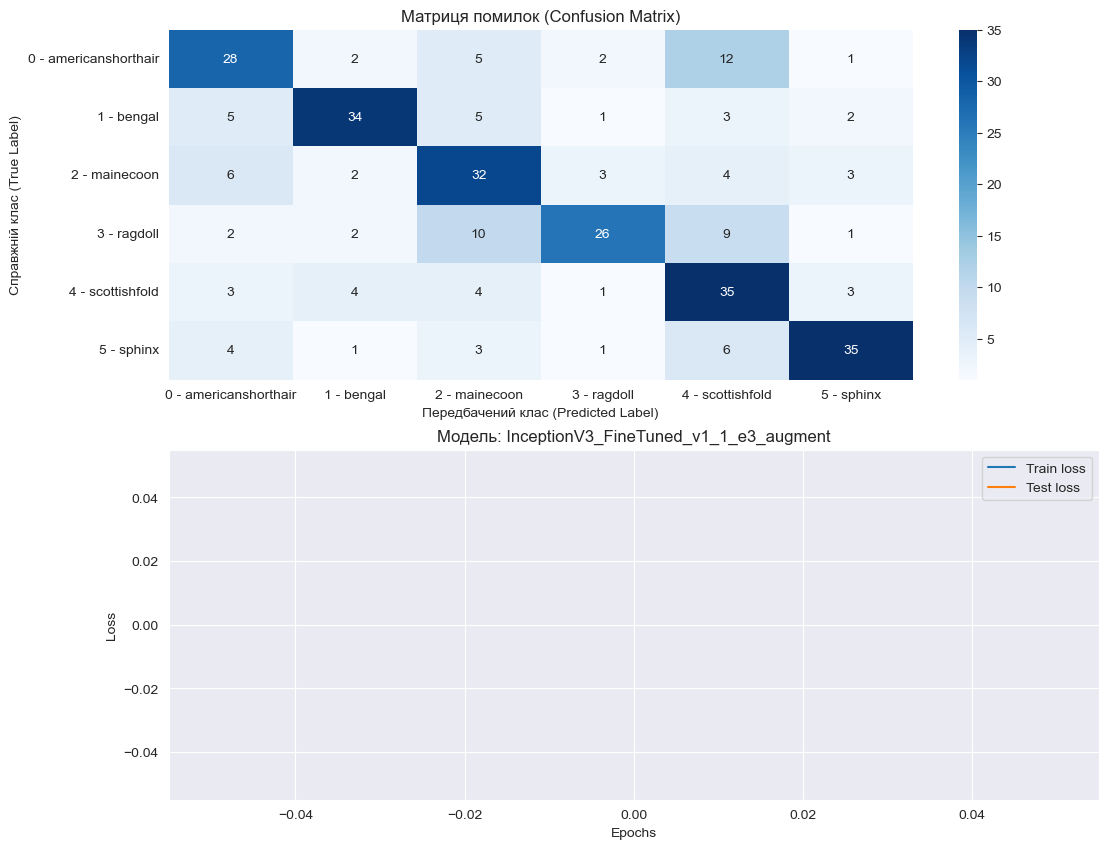

In [13]:
test_loss_var_3, y_preds_3, y_true_3 = test_step(model=my_model,
                                                 data_loader=test_dataloader,
                                                 loss_fn=criterion)
calc_metrics(y_preds=y_preds_3,y_true=y_true_3,epochs_train_lt=[], epochs_test_lt=[], epochs_num=0, model_name='InceptionV3_FineTuned_v1_1_e3_augment', num_classes=6)

In [22]:
predict_image(my_model, 'my_photo/20190906_113546.jpg', basic_transform, class_names)

('0 - americanshorthair', 0.6883700489997864)